In [54]:
import os
import pandas as pd
from datetime import datetime
from tools.scraper import *
from tools.montecarlo import *
from tools.trade import *

In [2]:
data_dir = f"data/{os.listdir("data")[-1]}" # most recent scrape
comp_dict = get_companies_dict()

In [3]:
# (x,y)
# After x days, returns must be at least y%
periods = [ 
    (30, 0.03),
    (90, 0.048),
    (180, 0.0768),
    (270, 0.122),
    (360, 0.2)
]

In [4]:
# Check tools.trade for a specification of judge
def judge(df: pd.DataFrame, ticker: str) -> None | Trade:
    if len(df) >= 361 and all([df["gain"].iloc[period] > gain for (period, gain) in periods]):
        return Trade(
            ticker,
            datetime.strptime(df.iloc[0]["date"], '%Y-%m-%d'),
            "Long",
            df.iloc[0]["price"],
            0.05,
            0.05,
            0.05
        )
    else:
        return None

In [5]:
def clean_df(df: pd.DataFrame, cik: str):
    df = pd.read_csv(f"{data_dir}/{cik}/ohclv.csv")
    df = df.iloc[::-1].reset_index(drop=True) # df[0] is now the most recent date
    df.columns = map(str.lower, df.columns)
    df["price"] = (df["open"]+df["close"])/2
    df["gain"] = (df.iloc[0]["close"]-df["close"])/df["close"] # Percentage gain from that day to the last day 
    return df

In [40]:
all_trades = []
i = 0
for cik in os.listdir(data_dir):
    if (i%100 == 0):
        print(i, len(all_trades))
        if (i==300):
            break
    comp: Company = comp_dict[cik]
    if os.path.exists(f"{data_dir}/{cik}/ohclv.csv"):
        ohclv = pd.read_csv(f"{data_dir}/{cik}/ohclv.csv")
        ohclv = clean_df(ohclv, cik)[:3650] # max 10 years in the past (can remove later)
        all_trades.extend(get_trades(ohclv, lambda df: judge(df, comp.ticker)))
    i += 1


0 0
100 8021
200 16054
300 24237


In [ ]:
# TODO:
    # Isn't 24000 trades very high?
        # Right now everything is max 10 years in the past
        # So per company, at most 10*12 trades (1 per month)
        # Overall, 10*12*300 = 36000 trades
        # Does it really make sense that we're doing 24000 trades?
    # Change everything to use percents (need to introduce lots of *100 and /100)
    # See last commit for todo notes

Max drawdown: -9.91864805609534%
Worst performance: 127.48269776781429%
Avg. % gain per trade: 0.19958286482785703
Winrate: 65.1854602467302 (%)
Average performance: 162.07498689208268%


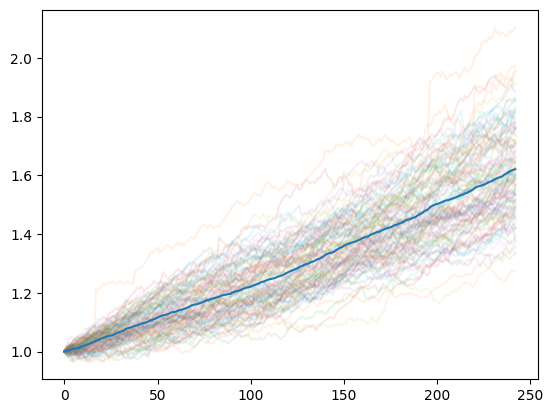

In [64]:
MonteCarlo(all_trades, 0.01, False).show(100)